# Feature Engineering

Machine Learning models cannot read English words. They need numbers. Here, we use TF-IDF to convert cleaned text into a matrix of numerical features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import show_top_ngrams_by_class, add_basic_meta_features, plot_dimensionality_reduction, save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


load cleaned text

In [3]:
processed_train = pd.read_csv(r'data/processed/processed_train.csv', dtype=str, quoting=0)
processed_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet


In [4]:
processed_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 79972 entries, 0 to 79971
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   review_target              79972 non-null  str  
 1   review_title               79972 non-null  str  
 2   review_content             79972 non-null  str  
 3   review_content_char_count  79972 non-null  str  
 4   review_content_word_count  79972 non-null  str  
 5   review_content_cleaned     79972 non-null  str  
 6   review_title_cleaned       79607 non-null  str  
dtypes: str(7)
memory usage: 4.3 MB


top unigrams, bigrams, and trigrams per class

In [5]:
feat_eng_train = processed_train.copy()


Top unigrams for class 1 and 2 of cleaned review

--- Top unigrams for class 1 ---
[('book', np.int64(22267)), ('like', np.int64(11613)), ('time', np.int64(9543)), ('good', np.int64(8317)), ('movie', np.int64(7780)), ('read', np.int64(6545)), ('product', np.int64(6364)), ('work', np.int64(6202)), ('really', np.int64(5892)), ('buy', np.int64(5447)), ('make', np.int64(5187)), ('money', np.int64(5070)), ('better', np.int64(5002)), ('bought', np.int64(4836)), ('great', np.int64(4585))]



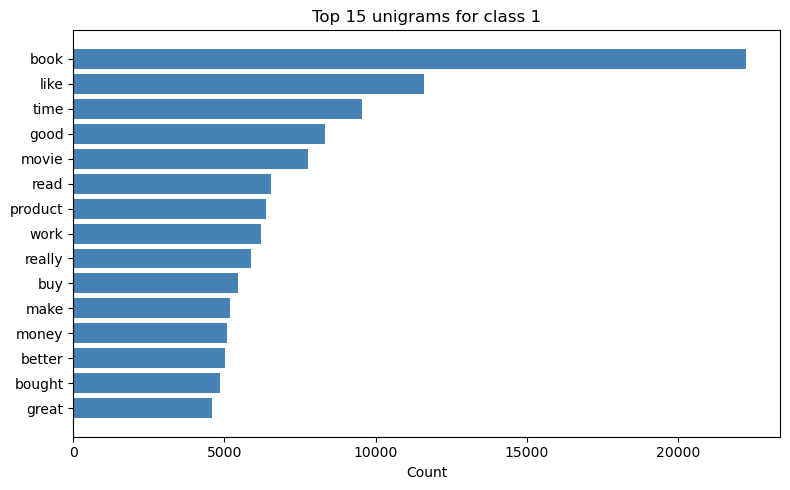

--- Top unigrams for class 2 ---
[('book', np.int64(23178)), ('great', np.int64(13512)), ('like', np.int64(10799)), ('good', np.int64(10496)), ('time', np.int64(8353)), ('read', np.int64(8136)), ('love', np.int64(7968)), ('movie', np.int64(6466)), ('really', np.int64(6304)), ('album', np.int64(5557)), ('cd', np.int64(5496)), ('work', np.int64(5403)), ('year', np.int64(5287)), ('make', np.int64(5260)), ('best', np.int64(5110))]



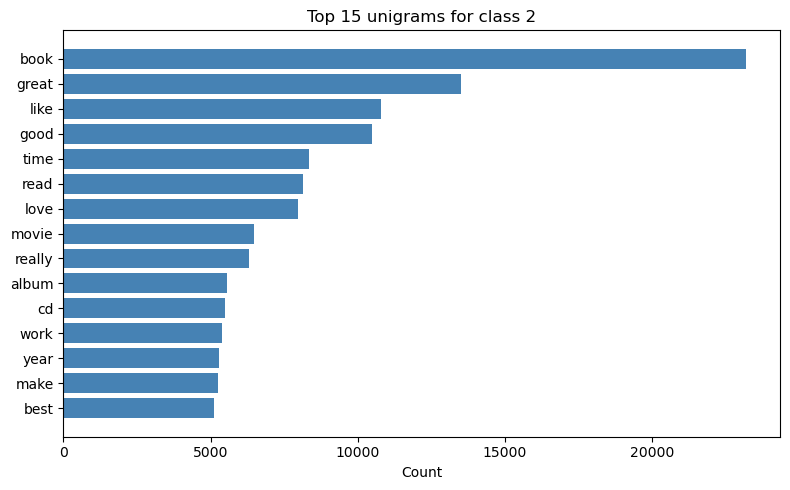

{'1': {(1, 1): [('book', np.int64(22267)),
   ('like', np.int64(11613)),
   ('time', np.int64(9543)),
   ('good', np.int64(8317)),
   ('movie', np.int64(7780)),
   ('read', np.int64(6545)),
   ('product', np.int64(6364)),
   ('work', np.int64(6202)),
   ('really', np.int64(5892)),
   ('buy', np.int64(5447)),
   ('make', np.int64(5187)),
   ('money', np.int64(5070)),
   ('better', np.int64(5002)),
   ('bought', np.int64(4836)),
   ('great', np.int64(4585))]},
 '2': {(1, 1): [('book', np.int64(23178)),
   ('great', np.int64(13512)),
   ('like', np.int64(10799)),
   ('good', np.int64(10496)),
   ('time', np.int64(8353)),
   ('read', np.int64(8136)),
   ('love', np.int64(7968)),
   ('movie', np.int64(6466)),
   ('really', np.int64(6304)),
   ('album', np.int64(5557)),
   ('cd', np.int64(5496)),
   ('work', np.int64(5403)),
   ('year', np.int64(5287)),
   ('make', np.int64(5260)),
   ('best', np.int64(5110))]}}

In [6]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(1, 1), top_k=15)


Top bigrams for class 1 and 2 of cleaned review

--- Top bigrams for class 1 ---
[('waste money', np.int64(1455)), ('read book', np.int64(983)), ('waste time', np.int64(928)), ('year old', np.int64(898)), ('look like', np.int64(688)), ('save money', np.int64(655)), ('sound like', np.int64(636)), ('book read', np.int64(618)), ('year ago', np.int64(497)), ('customer service', np.int64(464)), ('reading book', np.int64(425)), ('read review', np.int64(378))]



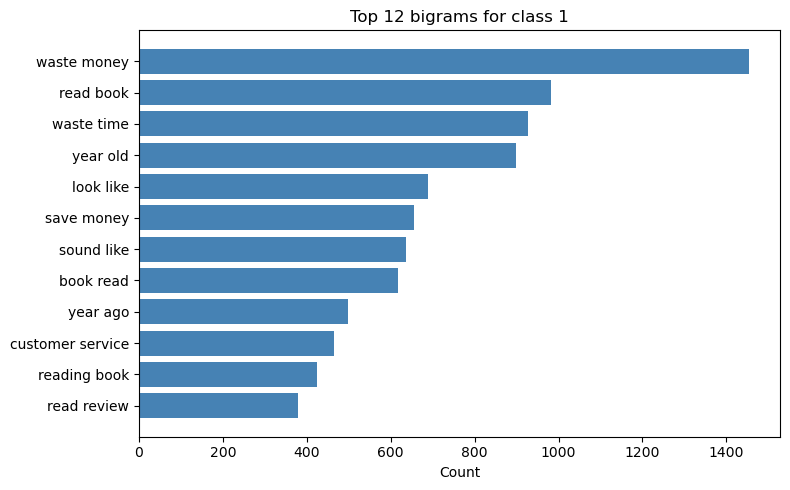

--- Top bigrams for class 2 ---
[('read book', np.int64(1421)), ('highly recommend', np.int64(1114)), ('year old', np.int64(1071)), ('book read', np.int64(914)), ('year ago', np.int64(690)), ('recommend book', np.int64(604)), ('great book', np.int64(558)), ('work great', np.int64(554)), ('long time', np.int64(534)), ('reading book', np.int64(511)), ('book great', np.int64(487)), ('highly recommended', np.int64(473))]



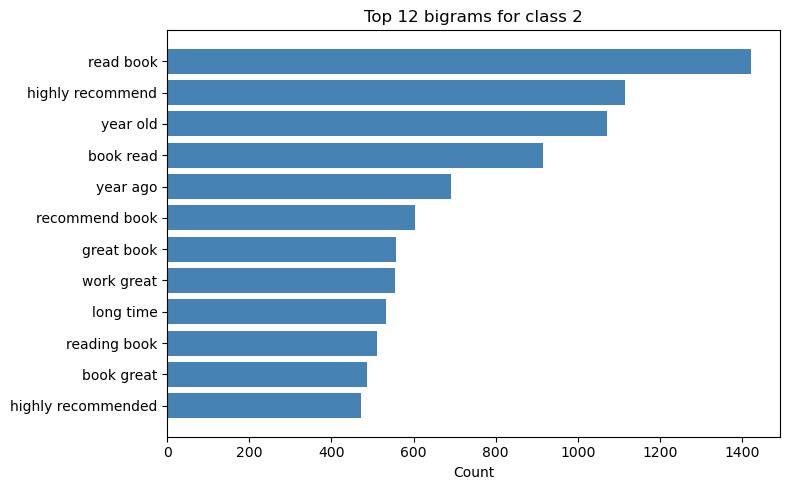

{'1': {(2, 2): [('waste money', np.int64(1455)),
   ('read book', np.int64(983)),
   ('waste time', np.int64(928)),
   ('year old', np.int64(898)),
   ('look like', np.int64(688)),
   ('save money', np.int64(655)),
   ('sound like', np.int64(636)),
   ('book read', np.int64(618)),
   ('year ago', np.int64(497)),
   ('customer service', np.int64(464)),
   ('reading book', np.int64(425)),
   ('read review', np.int64(378))]},
 '2': {(2, 2): [('read book', np.int64(1421)),
   ('highly recommend', np.int64(1114)),
   ('year old', np.int64(1071)),
   ('book read', np.int64(914)),
   ('year ago', np.int64(690)),
   ('recommend book', np.int64(604)),
   ('great book', np.int64(558)),
   ('work great', np.int64(554)),
   ('long time', np.int64(534)),
   ('reading book', np.int64(511)),
   ('book great', np.int64(487)),
   ('highly recommended', np.int64(473))]}}

In [7]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(2, 2), top_k=12)


Top trigrams for class 1 and 2 of cleaned review

--- Top 3-3grams for class 1 ---
[('waste time money', np.int64(236)), ('save money buy', np.int64(112)), ('worst book read', np.int64(87)), ('total waste money', np.int64(86)), ('complete waste money', np.int64(79)), ('worst movie seen', np.int64(74)), ('waste money time', np.int64(67)), ('complete waste time', np.int64(57)), ('year old son', np.int64(56)), ('hard earned money', np.int64(54)), ('really looking forward', np.int64(53)), ('book read like', np.int64(51))]



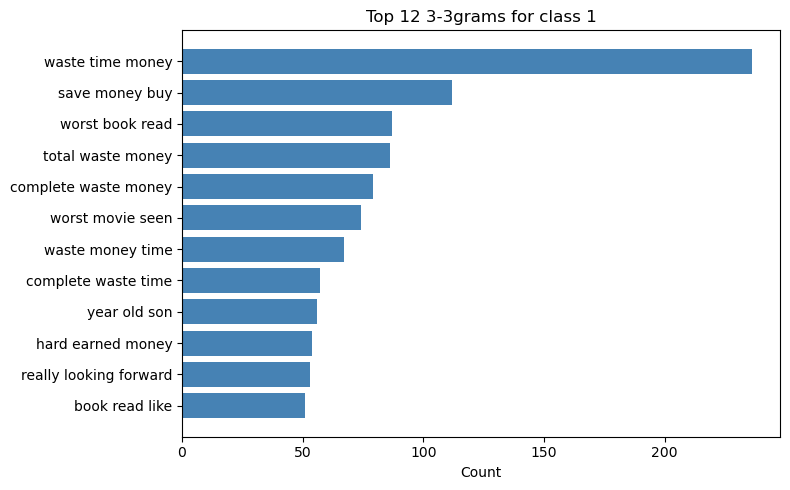

--- Top 3-3grams for class 2 ---
[('highly recommend book', np.int64(195)), ('best book read', np.int64(133)), ('year old son', np.int64(111)), ('year old daughter', np.int64(79)), ('book easy read', np.int64(70)), ('really enjoyed book', np.int64(68)), ('highly recommend product', np.int64(61)), ('book year ago', np.int64(56)), ('year old love', np.int64(54)), ('book read book', np.int64(46)), ('enjoyed reading book', np.int64(46)), ('couple year ago', np.int64(43))]



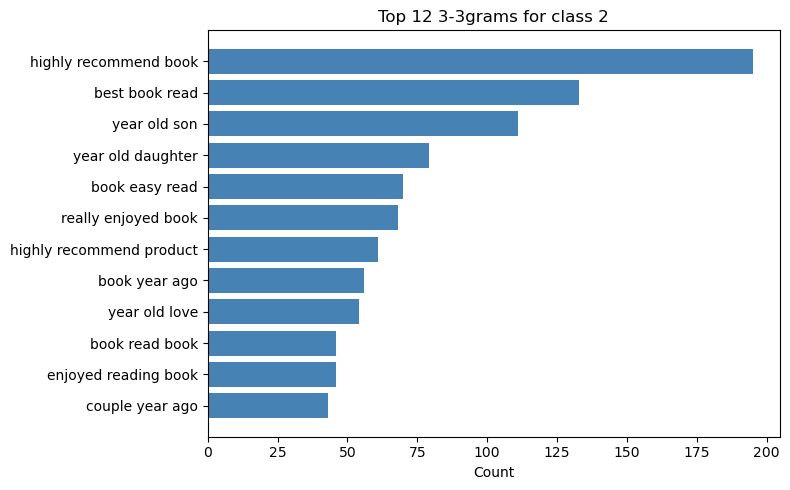

{'1': {(3, 3): [('waste time money', np.int64(236)),
   ('save money buy', np.int64(112)),
   ('worst book read', np.int64(87)),
   ('total waste money', np.int64(86)),
   ('complete waste money', np.int64(79)),
   ('worst movie seen', np.int64(74)),
   ('waste money time', np.int64(67)),
   ('complete waste time', np.int64(57)),
   ('year old son', np.int64(56)),
   ('hard earned money', np.int64(54)),
   ('really looking forward', np.int64(53)),
   ('book read like', np.int64(51))]},
 '2': {(3, 3): [('highly recommend book', np.int64(195)),
   ('best book read', np.int64(133)),
   ('year old son', np.int64(111)),
   ('year old daughter', np.int64(79)),
   ('book easy read', np.int64(70)),
   ('really enjoyed book', np.int64(68)),
   ('highly recommend product', np.int64(61)),
   ('book year ago', np.int64(56)),
   ('year old love', np.int64(54)),
   ('book read book', np.int64(46)),
   ('enjoyed reading book', np.int64(46)),
   ('couple year ago', np.int64(43))]}}

In [8]:
show_top_ngrams_by_class(feat_eng_train, 'review_target', 'review_content_cleaned', ngram_ranges=(3, 3), top_k=12)


Basic meta-features

In [9]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_content')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra,0,0,14,4.435185,455,0.776451
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great,0,0,12,5.488636,4,0.007018
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing,0,0,5,4.375000,3,0.014019
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340,0,0,2,4.705882,2,0.010363
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet,1,0,9,4.236842,4,0.020202


In [10]:
feat_eng_train = add_basic_meta_features(feat_eng_train, text_col='review_title')
feat_eng_train.head()

,review_target,review_title,review_content,review_content_char_count,review_content_word_count,review_content_cleaned,review_title_cleaned,review_content_exclamation_count,review_content_question_count,review_content_punctuation_count,review_content_avg_word_length,review_content_uppercase_count,review_content_uppercase_ratio,review_title_exclamation_count,review_title_question_count,review_title_punctuation_count,review_title_word_count,review_title_avg_word_length,review_title_uppercase_count,review_title_uppercase_ratio
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108,dx6340 year love picture good 35m easy use unl...,great camra,0,0,14,4.435185,455,0.776451,0,0,0,2,5.000000,10,0.909091
1,1,not so great,I'm using this book in an introductory organic...,570,88,using book introductory organic spectroscopy c...,not great,0,0,12,5.488636,4,0.007018,0,0,0,3,3.333333,0,0.000000
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40,read first chapter bombarded reference 199 end...,inaccurate disappointing,0,0,5,4.375000,3,0.014019,0,0,0,3,8.666667,1,0.035714
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34,feel cheaply made battery contact rusted soon ...,equus 3340,0,0,2,4.705882,2,0.010363,0,0,0,2,4.500000,1,0.100000
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38,love sheet sleek smooth really cool feel perfe...,awesome sheet,1,0,9,4.236842,4,0.020202,1,0,1,2,7.000000,0,0.000000


correlation with target

Convert target to numeric for correlation (fall back to category codes)

In [11]:
meta_cols= ['review_content_char_count', 'review_content_word_count', 'review_content_exclamation_count', 'review_content_question_count', 'review_content_punctuation_count', 'review_content_avg_word_length', 'review_content_uppercase_count', 'review_content_uppercase_ratio', 'review_title_exclamation_count', 'review_title_question_count', 'review_title_punctuation_count', 'review_title_word_count', 'review_title_avg_word_length', 'review_title_uppercase_count', 'review_title_uppercase_ratio']
try:
    target_numeric = pd.to_numeric(feat_eng_train['review_target'], errors='coerce')
    if target_numeric.isna().sum() > len(target_numeric) * 0.5:
        target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    else:
        target_numeric = target_numeric.fillna(0)
except Exception:
    target_numeric = feat_eng_train['review_target'].astype('category').cat.codes
    
corrs = {col: pd.Series(feat_eng_train[col]).corr(target_numeric) for col in meta_cols}
corr_series = pd.Series(corrs).sort_values(ascending=False)
print('Correlations between meta-features and target:')
print(corr_series)


Correlations between meta-features and target:
review_title_exclamation_count      0.031584
review_content_exclamation_count    0.027933
review_content_avg_word_length      0.013098
review_title_uppercase_ratio        0.004225
review_content_uppercase_ratio     -0.000912
review_title_uppercase_count       -0.001417
review_title_avg_word_length       -0.006423
review_content_uppercase_count     -0.019469
review_title_word_count            -0.021987
review_title_punctuation_count     -0.037998
review_content_char_count          -0.067318
review_content_punctuation_count   -0.069328
review_title_question_count        -0.070542
review_content_word_count          -0.071107
review_content_question_count      -0.090043
dtype: float64


`question_count (-0.190)`: `negative correlation`.    
This means that the `more questions` there are in the review, the more likely it is that the review will be `negative` (close to 0).

`word_count (-0.122)` & `char_count (-0.116)`: `negative correlation`.   
The `longer the review`, the more likely it is to be `negative`.

`uppercase_ratio (0.111)` & `uppercase_count (0.084)`: `positive correlation` (positive but weak).    
The `more capital letters`, the `more positive` the review tends to be.

`avg_word_length (-0.006)` & `punctuation_count (-0.018)`: These numbers are very close to zero.    
This means that these `features are almost useless` and do `not influence` whether the `review is positive or negative`.

ِApply fit and transform using TF-IDF for train dataset

In [12]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=20000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(feat_eng_train['review_content_cleaned'].astype(str))
print('Train TF-IDF shape:', X_train_tfidf.shape)

Train TF-IDF shape: (79972, 20000)


Visualize separability using dimensionality reduction (PCA and TSNE) for train dataset

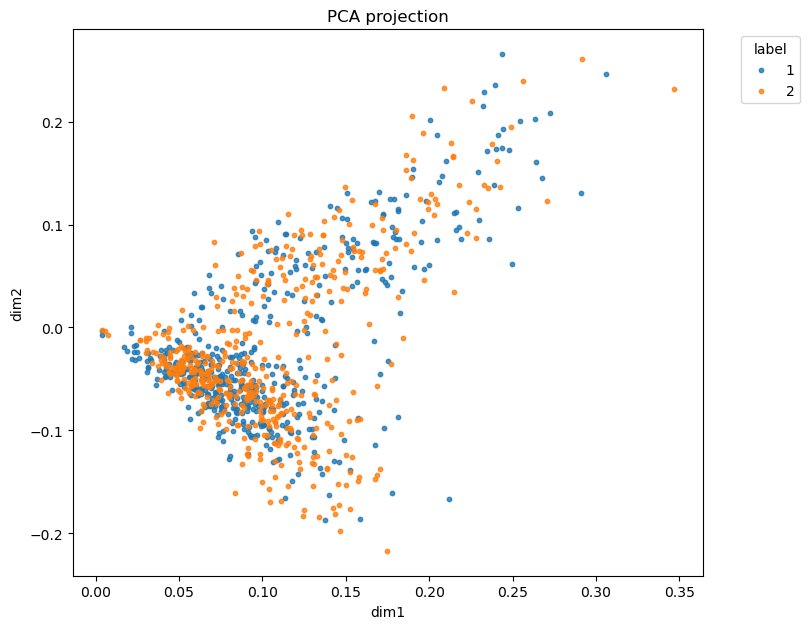

array([[ 0.09310007, -0.05241104],
       [ 0.13001108, -0.09886216],
       [ 0.0930794 , -0.06224365],
       ...,
       [ 0.1078721 ,  0.06668988],
       [ 0.06137685, -0.02710342],
       [ 0.06429021, -0.04825038]])

In [13]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='PCA')


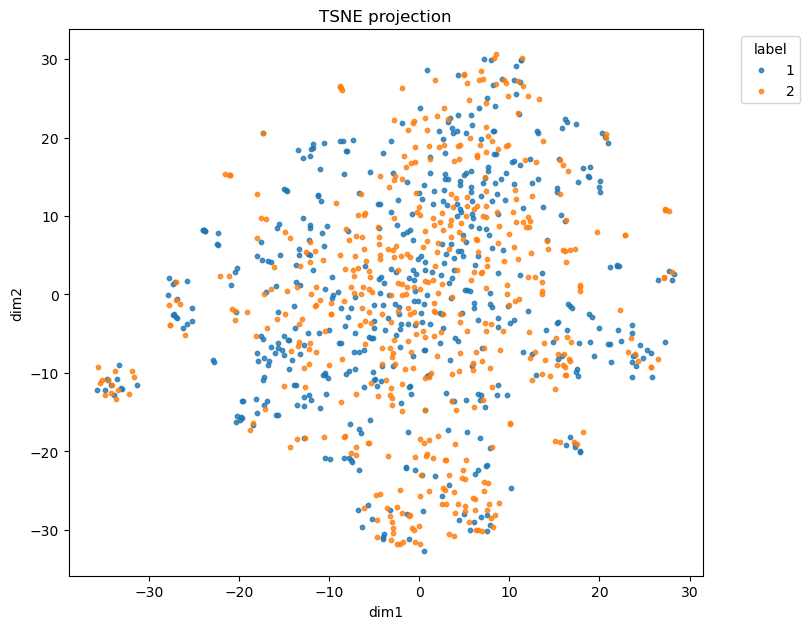

array([[ -1.2793605,  -1.6586918],
       [-13.738694 ,   3.7920287],
       [ -5.7423716, -18.871725 ],
       ...,
       [ 11.461283 ,   9.239615 ],
       [  5.3078294,   0.5775036],
       [-13.600362 , -14.125854 ]], dtype=float32)

In [14]:
plot_dimensionality_reduction(X_train_tfidf, feat_eng_train['review_target'], method='TSNE')


loadِ valid dataset to apply transform using TF-IDF 


In [15]:
processed_valid = pd.read_csv(r'data/processed/processed_valid.csv', dtype=str, quoting=0)
processed_valid.head()

,review_target,review_title,review_content,review_content_cleaned,review_title_cleaned
0,2,Everything you need,This is a wonderful book. It may have been mea...,wonderful book may meant clergy even though pr...,everything need
1,1,Important note about carrier,"The carrier is very cute, and lightweight...ho...",carrier very cute lightweight however frisky c...,important note carrier
2,1,Not a musical instrument -cannot be played,I bought (elsewhere) one of these harps for my...,bought elsewhere one harp daughter heart broke...,not musical instrument cannot played
3,2,Do I Iike this monitor? Well... I have 2!,I have 2 of these babies hooked up to a dual-o...,baby hooked dual output digital 256mb graphic ...,iike monitor well
4,1,Very disappointing,This book is very poorly written and lacks of ...,book very poorly written lack useful informati...,very disappointing


In [16]:
processed_valid.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
 4   review_title_cleaned    19909 non-null  str  
dtypes: str(5)
memory usage: 781.4 KB


In [17]:
X_valid_tfidf = tfidf_vectorizer.transform(processed_valid['review_content_cleaned'].astype(str))
print('Valid TF-IDF shape:', X_valid_tfidf.shape)

Valid TF-IDF shape: (20000, 20000)


Visualize separability using dimensionality reduction (PCA and TSNE) for valid dataset

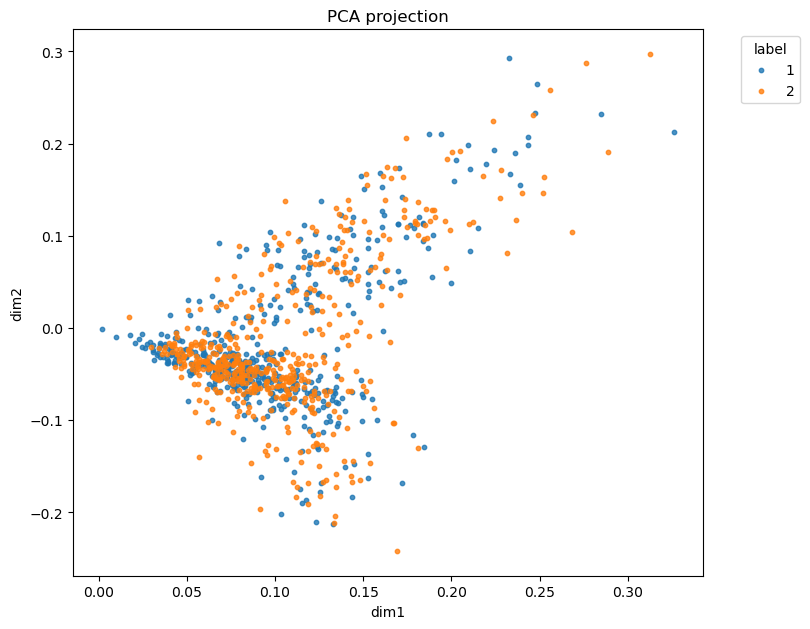

array([[ 0.10871537, -0.0409177 ],
       [ 0.15345194,  0.03961442],
       [ 0.12177898, -0.12841492],
       ...,
       [ 0.19019114,  0.12790182],
       [ 0.07737987, -0.05286973],
       [ 0.16126348,  0.10028255]])

In [18]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='PCA')


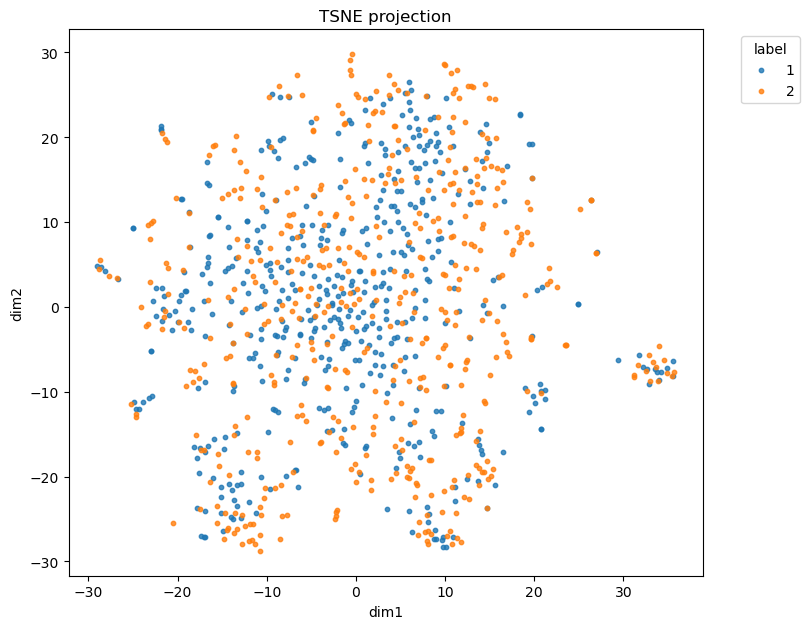

array([[ 16.849842 ,  -4.140752 ],
       [ 16.585224 ,  12.4455595],
       [ 13.925667 , -14.628446 ],
       ...,
       [ 10.306993 ,  17.357351 ],
       [ 26.970963 ,   6.3464684],
       [  9.26926  ,  15.850701 ]], dtype=float32)

In [19]:
plot_dimensionality_reduction(X_valid_tfidf, processed_valid['review_target'], method='TSNE')


loadِ valid and test dataset to apply transform using TF-IDF 


In [20]:
processed_test = pd.read_csv(r'data/processed/processed_test.csv', dtype=str, quoting=0)
processed_test.head()

,review_target,review_title,review_content,review_content_cleaned,review_title_cleaned
0,2,This is a great book,I must preface this by saying that I am not re...,must preface saying not religious but loved bo...,great book
1,1,Huge Disappointment.,"As a big time, long term Trevanian fan, I was ...",big time long term trevanian fan extremely dis...,huge disappointment
2,2,Wayne is tight but cant hang with Turk.,This album is hot as it wants to be. However C...,album hot want however cash money best album e...,wayne tight but cannot hang turk
3,2,Excellent,I read this book when I was in elementary scho...,read book elementary school probably fourth gr...,excellent
4,1,Not about Anusara,Although this book is touted on several Anusar...,although book touted several anusara web site ...,not anusara


In [21]:
processed_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_target           20000 non-null  str  
 1   review_title            19999 non-null  str  
 2   review_content          20000 non-null  str  
 3   review_content_cleaned  20000 non-null  str  
 4   review_title_cleaned    19926 non-null  str  
dtypes: str(5)
memory usage: 781.4 KB


In [22]:
X_test_tfidf = tfidf_vectorizer.transform(processed_test['review_content_cleaned'].astype(str))
print('Test TF-IDF shape:', X_test_tfidf.shape)

Test TF-IDF shape: (20000, 20000)


Visualize separability using dimensionality reduction (PCA and TSNE) for test dataset

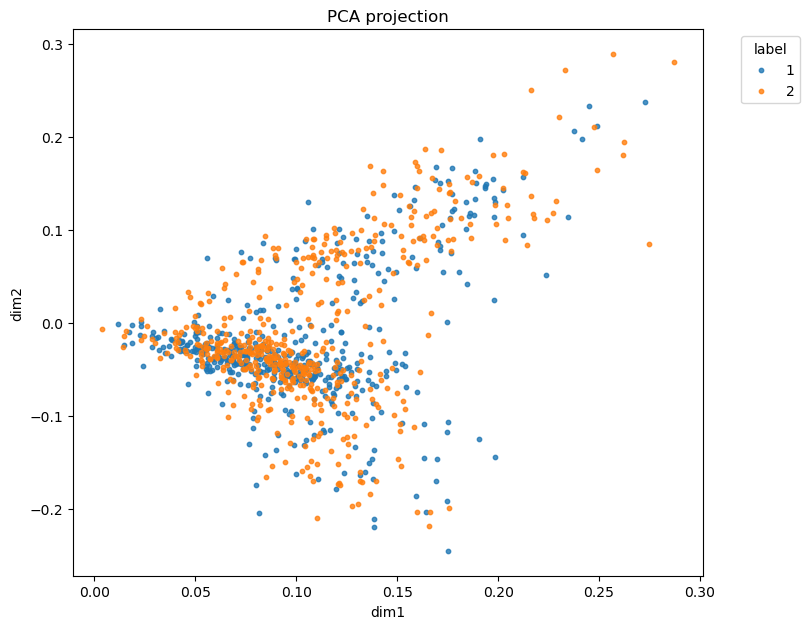

array([[ 0.11186904, -0.0553621 ],
       [ 0.05825319, -0.02768757],
       [ 0.17104491,  0.07853499],
       ...,
       [ 0.10560092,  0.07003539],
       [ 0.13580917, -0.15075191],
       [ 0.10724156, -0.07236498]])

In [23]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='PCA')


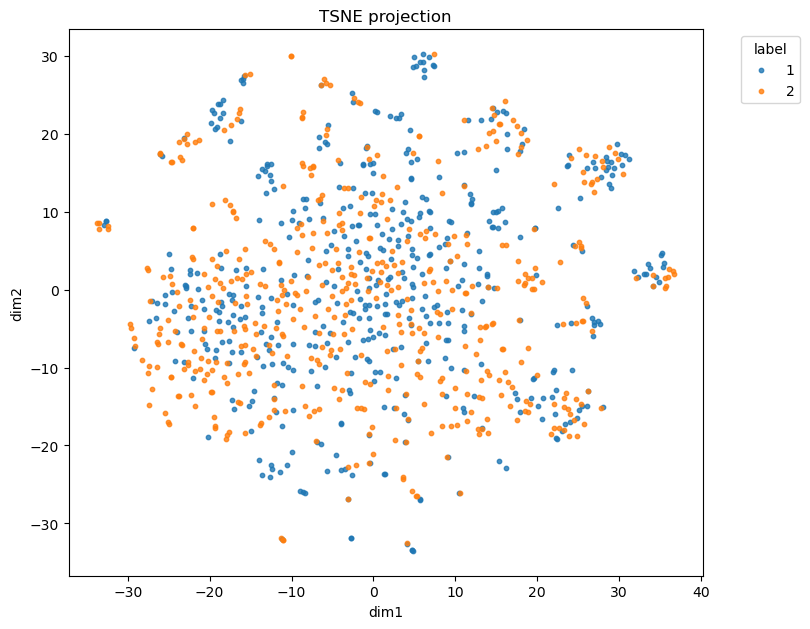

array([[  2.2292352 ,   7.7896204 ],
       [ 14.124156  ,   8.826929  ],
       [-14.199311  ,  -8.699168  ],
       ...,
       [ 13.94154   ,   0.26415333],
       [ 23.936735  , -16.940077  ],
       [ -7.6795263 ,  14.636976  ]], dtype=float32)

In [24]:
plot_dimensionality_reduction(X_test_tfidf, processed_test['review_target'], method='TSNE')


Save `train dataset` after apply feature engineering

In [25]:
save(df_base='data/processed', df=feat_eng_train, df_name='feat_eng_train.csv')

Saved dataframe feat_eng_train.csv to data/processed/feat_eng_train.csv


{'csv': PosixPath('data/processed/feat_eng_train.csv')}

save `tfidf_vectorizer` model, `X_train_tfidf`, and `y_train`

In [26]:
save(vectorizer_base='data/vectorizers', vectorizer=tfidf_vectorizer, vectorizer_name='tfidf_vectorizer.joblib', 
     vectors_base='data/vectorizers', vectors=X_train_tfidf, vectors_name="X_train_tfidf.npz",
     df_base='data/processed', df=feat_eng_train['review_target'], df_name='y_train.csv')

Saved dataframe y_train.csv to data/processed/y_train.csv


Saved vectorizer tfidf_vectorizer.joblib to data/vectorizers/tfidf_vectorizer.joblib
Saved vectors X_train_tfidf.npz to data/vectorizers/X_train_tfidf.npz


{'csv': PosixPath('data/processed/y_train.csv'),
 'vectorizer': PosixPath('data/vectorizers/tfidf_vectorizer.joblib'),
 'vectors': PosixPath('data/vectorizers/X_train_tfidf.npz')}

save the `X_valid_tfidf` and `y_valid`

In [27]:
save(vectors_base='data/vectorizers', vectors=X_valid_tfidf, vectors_name="X_valid_tfidf.npz",
     df_base='data/processed', df=processed_valid['review_target'], df_name='y_valid.csv')

Saved dataframe y_valid.csv to data/processed/y_valid.csv


Saved vectors X_valid_tfidf.npz to data/vectorizers/X_valid_tfidf.npz


{'csv': PosixPath('data/processed/y_valid.csv'),
 'vectors': PosixPath('data/vectorizers/X_valid_tfidf.npz')}

save the `X_test_tfidf` and `y_test`

In [28]:
save(vectors_base='data/vectorizers', vectors=X_test_tfidf, vectors_name="X_test_tfidf.npz",
     df_base='data/processed', df=processed_test['review_target'], df_name='y_test.csv')

Saved dataframe y_test.csv to data/processed/y_test.csv


Saved vectors X_test_tfidf.npz to data/vectorizers/X_test_tfidf.npz


{'csv': PosixPath('data/processed/y_test.csv'),
 'vectors': PosixPath('data/vectorizers/X_test_tfidf.npz')}